# Polynomial Regression Study

This notebook investigates how increasing polynomial complexity affects:

- Training error
- Validation error
- Overfitting
- Generalization performance

We experiment with polynomial degrees from 1 to 12 using PM2.5 prediction data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures # used to generate polynomial and interaction features from existing input features.
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import cross_val_score

In [3]:
# Load datasets
train_df = pd.read_csv("../data/processed/train.csv")
val_df   = pd.read_csv("../data/processed/val.csv")
test_df  = pd.read_csv("../data/processed/test.csv")

In [6]:
TARGET = "pm25"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

In [7]:
X_train.head()

,co,no2,nox,pm10,relativehumidity,temperature
0,2.84,168.1,0.1449,276.0,87.0,8.5
1,4.13,85.4,0.0499,339.0,88.0,13.3
2,2.86,63.7,0.1407,437.0,92.0,9.8
3,0.21,69.6,0.0386,271.0,51.0,15.1
4,2.12,205.9,0.1507,268.0,87.0,11.0


In [8]:
y_train.head()

0    149.0
1    229.0
2    285.0
3    101.0
4    122.0
Name: pm25, dtype: float64

In [9]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(814, 6)
(162, 6)
(110, 6)


##  Baseline Linear Regression Pipeline

In [10]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)

pred_train = baseline_model.predict(X_train)
pred_val   = baseline_model.predict(X_val)

train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))
val_rmse   = np.sqrt(mean_squared_error(y_val, pred_val))

print("Train RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Train RMSE: 20.39552847106202
Validation RMSE: 17.707039101919356


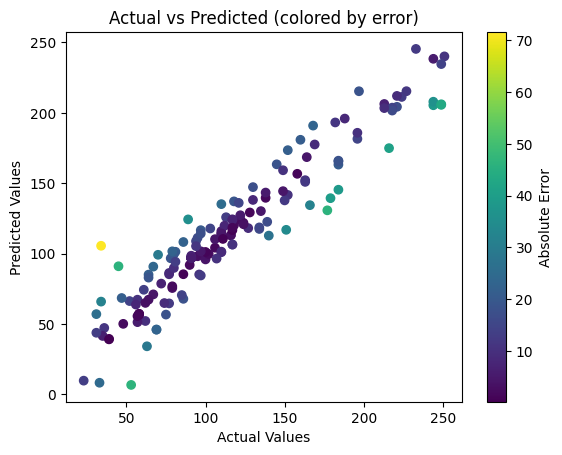

In [14]:
errors = np.abs(y_val - pred_val)

plt.scatter(y_val, pred_val, c=errors, cmap="viridis")
plt.colorbar(label="Absolute Error")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (colored by error)")
plt.show()

## Baseline Linear Regression Experiment

As an initial benchmark, a standard Linear Regression model was trained using the preprocessed environmental features.

### Pipeline Components
- **StandardScaler** → Normalizes feature distributions
- **LinearRegression** → Fits a linear relationship between features and PM2.5 concentration

### Objective
The purpose of this experiment is to establish a baseline performance before introducing polynomial feature expansion and regularization techniques.

### Results

| Metric | RMSE |
|---|---:|
| Training RMSE | 20.40 |
| Validation RMSE | 17.71 |

### Observations
- The model achieved relatively similar training and validation errors.
- Validation error being slightly lower than training error suggests the model is currently not overfitting.
- Since this is a purely linear model, its representational capacity is limited and may underfit complex environmental relationships.
- This baseline will be used as a reference point for later polynomial regression experiments.

### Next Steps
- Perform polynomial feature expansion (Degree 1 → 12)
- Compare training vs validation RMSE
- Visualize the bias–variance tradeoff
- Identify the degree where overfitting begins

# Polynomial Degree Sweep (1 → 12)

This becomes the bridge into your later bias–variance notebook.

- systematically increase model complexity
- record train + validation RMSE
- visualize divergence
- observe overfitting emerging

In [21]:
degrees = range(1, 13)

train_rmse_list = []
val_rmse_list = []

for degree in degrees:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree)),
        ("model", LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    train_rmse_list.append(train_rmse)
    val_rmse_list.append(val_rmse)

    print(
        f"Degree {degree} | "
        f"Train RMSE: {train_rmse:.2f} | "
        f"Validation RMSE: {val_rmse:.2f}"
    )

Degree 1 | Train RMSE: 20.40 | Validation RMSE: 17.71
Degree 2 | Train RMSE: 17.99 | Validation RMSE: 14.48
Degree 3 | Train RMSE: 14.34 | Validation RMSE: 13.42
Degree 4 | Train RMSE: 9.31 | Validation RMSE: 14.75
Degree 5 | Train RMSE: 5.05 | Validation RMSE: 86.23
Degree 6 | Train RMSE: 1.45 | Validation RMSE: 71611.67
Degree 7 | Train RMSE: 1.41 | Validation RMSE: 34072.29
Degree 8 | Train RMSE: 1.38 | Validation RMSE: 642259.59
Degree 9 | Train RMSE: 1.26 | Validation RMSE: 5231504.09
Degree 10 | Train RMSE: 1.25 | Validation RMSE: 2756744.09
Degree 11 | Train RMSE: 1.24 | Validation RMSE: 701010.68
Degree 12 | Train RMSE: 1.24 | Validation RMSE: 498128.84


In [22]:
results_df = pd.DataFrame({
    "degree": list(degrees),
    "train_rmse": train_rmse_list,
    "val_rmse": val_rmse_list
})

results_df

,degree,train_rmse,val_rmse
0,1,20.395528,1.770704e+01
1,2,17.991911,1.448344e+01
2,3,14.340579,1.341510e+01
3,4,9.311577,1.474627e+01
4,5,5.051550,8.622553e+01
5,6,1.445253,7.161167e+04
6,7,1.414608,3.407229e+04
7,8,1.382693,6.422596e+05
8,9,1.261392,5.231504e+06
9,10,1.250954,2.756744e+06


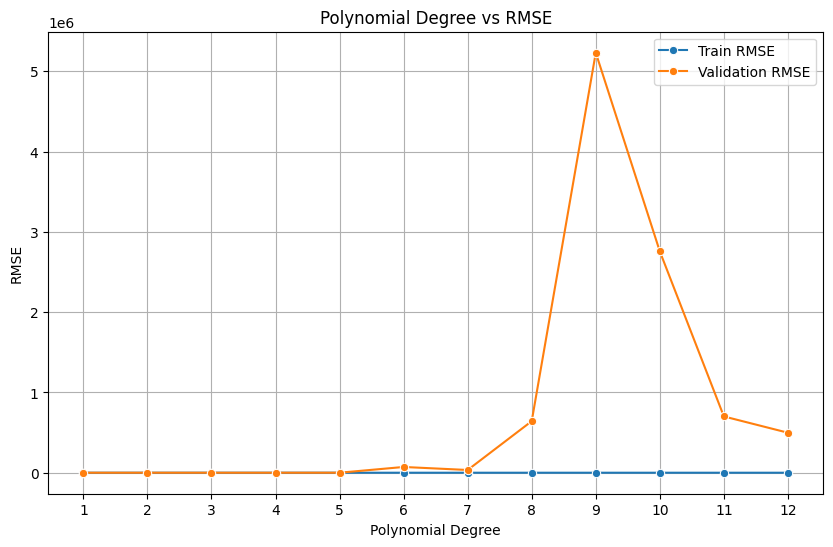

In [26]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=results_df,
    x="degree",
    y="train_rmse",
    marker="o",
    label="Train RMSE"
)

sns.lineplot(
    data=results_df,
    x="degree",
    y="val_rmse",
    marker="o",
    label="Validation RMSE"
)

plt.title("Polynomial Degree vs RMSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.xticks(range(1, 13))
plt.grid(True)
plt.savefig("../results/polynomial_degree_rmse_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Polynomial Degree vs Model Performance — Observations

This experiment evaluates how increasing polynomial complexity affects model performance on PM2.5 prediction, using training and validation RMSE as indicators of fit and generalization.

---

### Key Observations

- **Low-degree models (Degree 1-3)** show consistent improvement in both training and validation performance.
  - Validation RMSE decreases from **17.71 -> 13.42**, indicating that introducing mild non-linearity helps capture meaningful patterns in the data.

- **Moderate complexity (Degree 4)** appears to be a turning point:
  - Training error continues to decrease (**9.31 RMSE**),
  - but validation error increases (**14.75 RMSE**),
  - suggesting the onset of overfitting.

- **High-degree polynomials (Degree 5 and above)** demonstrate severe overfitting:
  - Training RMSE rapidly approaches very low values (~1.2-1.4),
  - while validation RMSE becomes extremely unstable and explodes (e.g., **86 -> 71,611 -> millions**).

- The extreme spikes in validation error indicate:
  - strong sensitivity to noise,
  - numerical instability caused by high-dimensional polynomial expansion,
  - and a complete breakdown of generalization.

---

### Core Insight

This experiment clearly demonstrates the **bias-variance tradeoff**:

- **Low-degree models** -> high bias (underfitting)
- **Mid-degree models** -> balanced performance
- **High-degree models** -> high variance (overfitting)

The best generalization performance appears around **Degree 3-4**, where validation error is minimized before overfitting begins.

---

### Conclusion

Increasing polynomial complexity improves model expressiveness only up to a certain point. Beyond that, the model begins to memorize noise in the training data instead of learning general patterns, leading to drastic deterioration in validation performance.

This highlights the importance of:
- controlling model complexity,
- using regularization techniques (Ridge/Lasso),
- and relying on validation performance rather than training performance alone.